# Практична робота: Множинна лінійна регресія методом градієнтного спуску
**Мета:** реалізувати MLR з нуля (градієнтний спуск), провести EDA і перевірити 6 припущень МНК.

Інструкція: запусти клітинки по порядку.


In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn statsmodels scipy

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from scipy import stats

# Встановлення стилю графіків
sns.set_style("whitegrid")
%matplotlib inline

In [2]:
filename = "Student_Performance.csv"  
if not os.path.exists(filename):
    raise FileNotFoundError(f"Файл {filename} не знайдено в поточній папці: {os.getcwd()}")

data = pd.read_csv(filename)
print("=" * 50)
print("ДОСТУПНІ СТОВПЦІ В ДАТАСЕТІ:")
print("=" * 50)
print(data.columns.tolist())
print("\n" + "=" * 50)
print("ПЕРШІ 5 РЯДКІВ ДАТАСЕТУ:")
print("=" * 50)
display(data.head())


ДОСТУПНІ СТОВПЦІ В ДАТАСЕТІ:
['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index']

ПЕРШІ 5 РЯДКІВ ДАТАСЕТУ:


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [3]:
# Якщо назва таргету є 'Performance Index' — використовуємо її, інакше беремо останній стовпець
possible_targets = ["Performance Index", "Performance_Index", "PerformanceIndex", 
                    "performance_index", "performance index"]
target_column = None
for candidate in possible_targets:
    if candidate in data.columns:
        target_column = candidate
        break
        
if target_column is None:
    # беремо останній стовпець як таргет (і виводимо повідомлення)
    target_column = data.columns[-1]
    print(f"\n⚠️  Увага: 'Performance Index' не знайдено.")
    print(f"   Автоматично обрано таргет: '{target_column}'")

print(f"\n✓ Обраний таргет для моделювання: {target_column}")


✓ Обраний таргет для моделювання: Performance Index



ІНФОРМАЦІЯ ПРО ДАТАФРЕЙМ:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


None


СТАТИСТИЧНИЙ ОПИС ВСІХ ЗМІННИХ:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Hours Studied,10000.0,NaN,NaN,NaN,4.9929,2.589309,1.0,3.0,5.0,7.0,9.0
Previous Scores,10000.0,NaN,NaN,NaN,69.4457,17.343152,40.0,54.0,69.0,85.0,99.0
Extracurricular Activities,10000,2,No,5052,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep Hours,10000.0,NaN,NaN,NaN,6.5306,1.695863,4.0,5.0,7.0,8.0,9.0
Sample Question Papers Practiced,10000.0,NaN,NaN,NaN,4.5833,2.867348,0.0,2.0,5.0,7.0,9.0
Performance Index,10000.0,NaN,NaN,NaN,55.2248,19.212558,10.0,40.0,55.0,71.0,100.0



ПРОПУЩЕНІ ЗНАЧЕННЯ ПО СТОВПЦЯХ:
✓ Пропущених значень немає


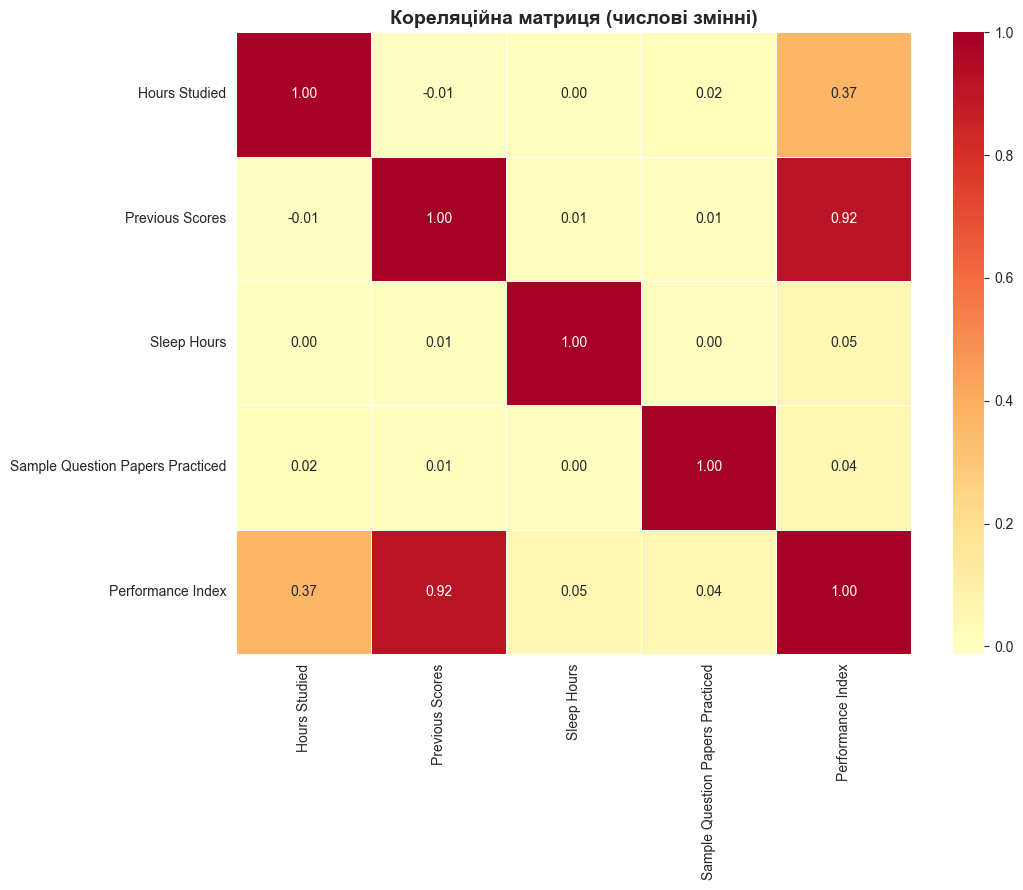

In [4]:
# --- 3. EDA ---
print("\n" + "=" * 50)
print("ІНФОРМАЦІЯ ПРО ДАТАФРЕЙМ:")
print("=" * 50)
display(data.info())

print("\n" + "=" * 50)
print("СТАТИСТИЧНИЙ ОПИС ВСІХ ЗМІННИХ:")
print("=" * 50)
display(data.describe(include='all').T)

# Пропущені значення
print("\n" + "=" * 50)
print("ПРОПУЩЕНІ ЗНАЧЕННЯ ПО СТОВПЦЯХ:")
print("=" * 50)
missing_vals = data.isnull().sum()
print(missing_vals[missing_vals > 0] if missing_vals.sum() > 0 else "✓ Пропущених значень немає")

# Матриця кореляції (тільки числові)
numerical_data = data.select_dtypes(include=[np.number])
if numerical_data.shape[1] > 1:
    fig, ax = plt.subplots(figsize=(11, 9))
    sns.heatmap(numerical_data.corr(), annot=True, fmt=".2f", cmap="RdYlBu_r", 
                center=0, linewidths=0.5, ax=ax)
    ax.set_title("Кореляційна матриця (числові змінні)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  У наборі недостатньо числових змінних для побудови heatmap.")

In [5]:
# --- 4. Обробка категоріальних змінних ---
# Розділимо фічі на числові та категоріальні (object або категоріальні)
features = data.drop(columns=[target_column])
target = data[target_column].values

numerical_features = features.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = features.select_dtypes(include=['object', 'category']).columns.tolist()

print("\n" + "=" * 50)
print("ТИПИ ОЗНАК:")
print("=" * 50)
print(f"Числові стовпці ({len(numerical_features)}): {numerical_features}")
print(f"Категоріальні стовпці ({len(categorical_features)}): {categorical_features}")

# Простий підхід: для бінарних категорій мапимо вручну, для мультикат - one-hot
# Побудуємо ColumnTransformer
transformation_steps = []

if categorical_features:
    # OneHotEncoder для категоріальних
    transformation_steps.append((
        'categorical',
        OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'),
        categorical_features
    ))

# Для числових залишимо як є (StandardScaler застосуємо пізніше)
if numerical_features:
    transformation_steps.append(('numerical', 'passthrough', numerical_features))

if transformation_steps:
    column_processor = ColumnTransformer(transformers=transformation_steps, remainder='drop')
    features_transformed = column_processor.fit_transform(features)

    # Формуємо імена ознак
    all_feature_names = []
    encoded_names = []
    
    if categorical_features:
        encoder = column_processor.named_transformers_['categorical']
        categories_list = encoder.categories_
        for column_name, category_values in zip(categorical_features, categories_list):
            # drop='first' => пропускаємо перше значення
            for value in category_values[1:]:
                encoded_names.append(f"{column_name}_{value}")
                
    all_feature_names = encoded_names + numerical_features
    features_processed = pd.DataFrame(features_transformed, columns=all_feature_names)
else:
    features_processed = features[numerical_features].copy()
    all_feature_names = features_processed.columns.tolist()

print("\n" + "=" * 50)
print(f"ФІНАЛЬНИЙ СПИСОК ОЗНАК ({len(all_feature_names)}):")
print("=" * 50)
print(all_feature_names)
print("\nПерегляд оброблених даних:")
display(features_processed.head())


ТИПИ ОЗНАК:
Числові стовпці (4): ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']
Категоріальні стовпці (1): ['Extracurricular Activities']

ФІНАЛЬНИЙ СПИСОК ОЗНАК (5):
['Extracurricular Activities_Yes', 'Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']

Перегляд оброблених даних:


,Extracurricular Activities_Yes,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced
0,1.0,7.0,99.0,9.0,1.0
1,0.0,4.0,82.0,4.0,2.0
2,1.0,8.0,51.0,7.0,2.0
3,1.0,5.0,52.0,5.0,2.0
4,0.0,7.0,75.0,8.0,5.0


In [6]:
# --- 5. Поділ на train/test та стандартизація ---
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    features_processed.values, target, test_size=0.2, random_state=42
)

normalizer = StandardScaler()
X_train_normalized = normalizer.fit_transform(X_train_raw)
X_test_normalized = normalizer.transform(X_test_raw)

# Додаємо стовпчик одиниць для інтерсепту
X_train_with_intercept = np.c_[np.ones(X_train_normalized.shape[0]), X_train_normalized]
X_test_with_intercept = np.c_[np.ones(X_test_normalized.shape[0]), X_test_normalized]

print("\n" + "=" * 50)
print("РОЗМІРИ TRAIN/TEST ВИБІРОК:")
print("=" * 50)
print(f"X_train: {X_train_with_intercept.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test_with_intercept.shape}, y_test:  {y_test.shape}")


РОЗМІРИ TRAIN/TEST ВИБІРОК:
X_train: (8000, 6), y_train: (8000,)
X_test:  (2000, 6), y_test:  (2000,)


In [7]:
# --- 6. Реалізація градієнтного спуску з нуля ---
def calculate_mse(X, y, coefficients):
    """
    MSE (mean squared error) for parameters coefficients.
    X: (n_samples, n_features)
    y: (n_samples,)
    coefficients: (n_features,) or (n_features,1)
    """
    num_samples = len(y)
    predictions = X.dot(coefficients)
    errors = predictions - y
    mse_value = (1.0 / num_samples) * np.sum(errors ** 2)
    return mse_value

def train_gradient_descent(X, y, initial_coeffs=None, lr=0.01, max_iterations=1000, 
                          tolerance=None, show_progress=False):
    """
    Градієнтний спуск для лінійної регресії
    """
    n_samples, n_features = X.shape
    if initial_coeffs is None:
        coeffs = np.zeros(n_features)
    else:
        coeffs = initial_coeffs.copy()
        
    loss_history = []
    
    for iteration in range(max_iterations):
        predictions = X.dot(coeffs)
        errors = predictions - y
        gradient = (2.0 / n_samples) * X.T.dot(errors)   # похідна MSE
        coeffs = coeffs - lr * gradient
        
        current_loss = calculate_mse(X, y, coeffs)
        loss_history.append(current_loss)
        
        if show_progress and (iteration % (max_iterations//10 + 1) == 0):
            print(f"Ітерація {iteration+1}/{max_iterations}, Loss={current_loss:.6f}")
            
        if tolerance is not None and iteration > 0:
            if abs(loss_history[-2] - loss_history[-1]) < tolerance:
                if show_progress:
                    print(f"✓ Рання зупинка за толерантністю на ітерації {iteration+1}")
                break
                
    return coeffs, loss_history


In [8]:
# --- 7. Навчання ---
# Налаштування гіперпараметрів
LEARNING_RATE = 0.01
MAX_EPOCHS = 5000

print("\n" + "=" * 50)
print("НАВЧАННЯ МОДЕЛІ (ГРАДІЄНТНИЙ СПУСК):")
print("=" * 50)
print(f"Learning rate: {LEARNING_RATE}")
print(f"Максимальна кількість ітерацій: {MAX_EPOCHS}")
print()

initial_coefficients = np.zeros(X_train_with_intercept.shape[1])
trained_coefficients, training_losses = train_gradient_descent(
    X_train_with_intercept, y_train, 
    initial_coeffs=initial_coefficients, 
    lr=LEARNING_RATE, 
    max_iterations=MAX_EPOCHS, 
    show_progress=True
)

print("\n" + "=" * 50)
print("НАВЧЕНІ КОЕФІЦІЄНТИ МОДЕЛІ:")
print("=" * 50)
for idx, coefficient in enumerate(trained_coefficients):
    feature_name = "Intercept (вільний член)" if idx == 0 else all_feature_names[idx-1]
    print(f"{feature_name:40s}: {coefficient:>10.6f}")


НАВЧАННЯ МОДЕЛІ (ГРАДІЄНТНИЙ СПУСК):
Learning rate: 0.01
Максимальна кількість ітерацій: 5000

Ітерація 1/5000, Loss=3292.539047
Ітерація 502/5000, Loss=4.169741
Ітерація 1003/5000, Loss=4.169736
Ітерація 1504/5000, Loss=4.169736
Ітерація 2005/5000, Loss=4.169736
Ітерація 2506/5000, Loss=4.169736
Ітерація 3007/5000, Loss=4.169736
Ітерація 3508/5000, Loss=4.169736
Ітерація 4009/5000, Loss=4.169736
Ітерація 4510/5000, Loss=4.169736

НАВЧЕНІ КОЕФІЦІЄНТИ МОДЕЛІ:
Intercept (вільний член)                :  55.311500
Extracurricular Activities_Yes          :   0.304291
Hours Studied                           :   7.401341
Previous Scores                         :  17.637271
Sleep Hours                             :   0.810031
Sample Question Papers Practiced        :   0.548842


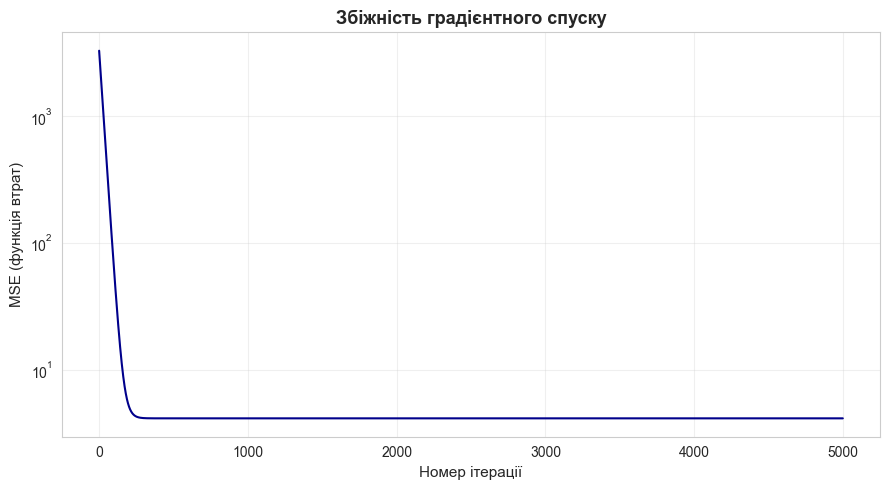

In [9]:
# Графік збіжності функції втрат
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(training_losses, color='darkblue', linewidth=1.5)
ax.set_xlabel("Номер ітерації", fontsize=11)
ax.set_ylabel("MSE (функція втрат)", fontsize=11)
ax.set_title("Збіжність градієнтного спуску", fontsize=13, fontweight='bold')
ax.set_yscale('log')  # іноді корисно бачити в логшкалі
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# --- 8. Прогнози та метрики ---
predictions_test = X_test_with_intercept.dot(trained_coefficients)
test_mse = mean_squared_error(y_test, predictions_test)
test_r2 = r2_score(y_test, predictions_test)

# Бейзлайн: завжди прогноз = середнє y_train
baseline_predictions = np.full_like(y_test, np.mean(y_train))
baseline_mse = mean_squared_error(y_test, baseline_predictions)

print("\n" + "=" * 50)
print("МЕТРИКИ ЯКОСТІ МОДЕЛІ (TEST SET):")
print("=" * 50)
print(f"MSE (Mean Squared Error):     {test_mse:.4f}")
print(f"R² (коефіцієнт детермінації): {test_r2:.4f}")
print(f"Baseline MSE (predict mean):  {baseline_mse:.4f}")
print(f"Покращення над baseline:      {((baseline_mse - test_mse) / baseline_mse * 100):.2f}%")



МЕТРИКИ ЯКОСТІ МОДЕЛІ (TEST SET):
MSE (Mean Squared Error):     4.0826
R² (коефіцієнт детермінації): 0.9890
Baseline MSE (predict mean):  370.7730
Покращення над baseline:      98.90%


In [11]:
# --- 9. Перевірка 6 припущень МНК -- підготовка залишків ---
test_residuals = y_test - predictions_test
fitted_values = predictions_test
n_test_samples = len(y_test)

print("\n" + "=" * 70)
print("ПЕРЕВІРКА ПРИПУЩЕНЬ ЛІНІЙНОЇ РЕГРЕСІЇ (МНК):")
print("=" * 70)


ПЕРЕВІРКА ПРИПУЩЕНЬ ЛІНІЙНОЇ РЕГРЕСІЇ (МНК):


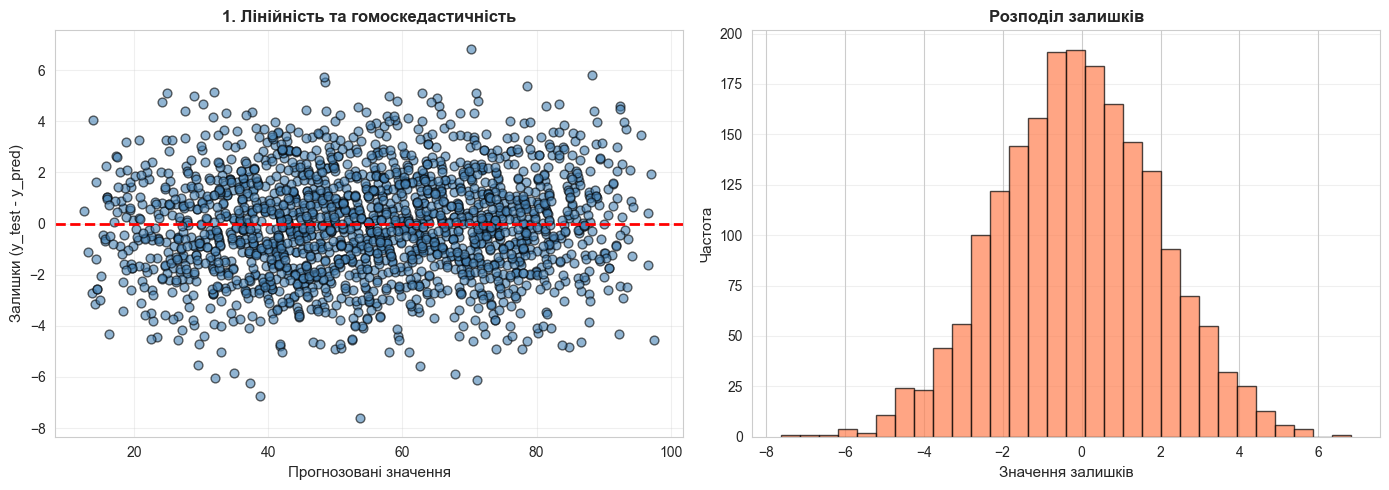

In [12]:
# 1) Лінійність / графік залишків vs прогнозів
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(fitted_values, test_residuals, alpha=0.6, color='steelblue', edgecolors='k', s=40)
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel("Прогнозовані значення", fontsize=11)
axes[0].set_ylabel("Залишки (y_test - y_pred)", fontsize=11)
axes[0].set_title("1. Лінійність та гомоскедастичність", fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Гистограма залишків
axes[1].hist(test_residuals, bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title("Розподіл залишків", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Значення залишків", fontsize=11)
axes[1].set_ylabel("Частота", fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


In [13]:
# 2) Відсутність мультиколінеарності: розрахунок VIF (потрібен DataFrame ознак без інтерсепту)
print("\n" + "=" * 70)
print("2. МУЛЬТИКОЛІНЕАРНІСТЬ (VIF - Variance Inflation Factor):")
print("=" * 70)
X_for_vif = pd.DataFrame(X_train_normalized, columns=all_feature_names)
vif_results = pd.DataFrame()
vif_results['Ознака'] = X_for_vif.columns
vif_results['VIF'] = [variance_inflation_factor(X_for_vif.values, i) 
                       for i in range(X_for_vif.shape[1])]
vif_results = vif_results.sort_values('VIF', ascending=False)
print("Інтерпретація: VIF < 5 (добре), 5-10 (помірна колінеарність), >10 (висока колінеарність)")
display(vif_results)


2. МУЛЬТИКОЛІНЕАРНІСТЬ (VIF - Variance Inflation Factor):
Інтерпретація: VIF < 5 (добре), 5-10 (помірна колінеарність), >10 (висока колінеарність)


,Ознака,VIF
3,Sleep Hours,1.000461
0,Extracurricular Activities_Yes,1.000428
1,Hours Studied,1.000387
4,Sample Question Papers Practiced,1.000320
2,Previous Scores,1.000243



3. НОРМАЛЬНІСТЬ ЗАЛИШКІВ:


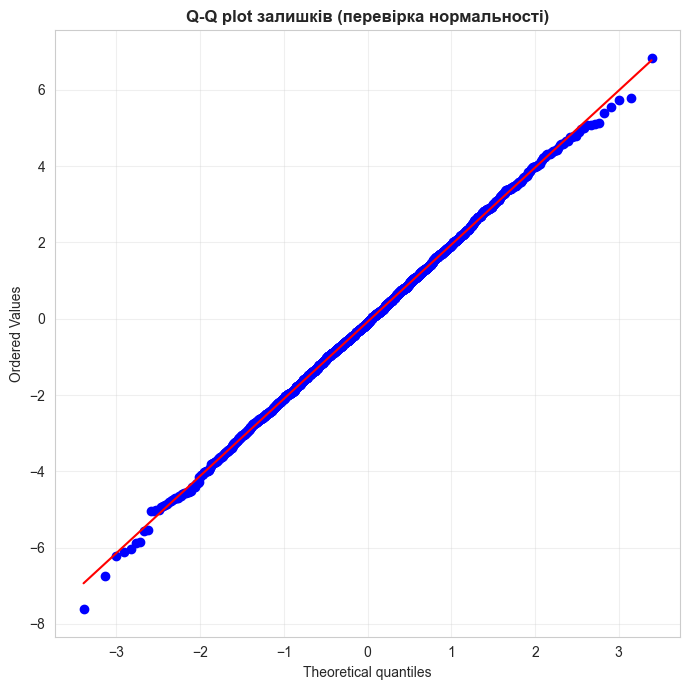

Shapiro-Wilk test:
  Статистика = 0.9996, p-value = 0.9751
Jarque-Bera test:
  Статистика = 0.0852, p-value = 0.9583
Інтерпретація: p > 0.05 → залишки нормально розподілені


In [14]:
# 3) Нормальність залишків
print("\n" + "=" * 70)
print("3. НОРМАЛЬНІСТЬ ЗАЛИШКІВ:")
print("=" * 70)

# QQ-plot
fig, ax = plt.subplots(figsize=(7, 7))
stats.probplot(test_residuals, dist="norm", plot=ax)
ax.set_title("Q-Q plot залишків (перевірка нормальності)", fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Тести нормальності
shapiro_statistic, shapiro_pvalue = stats.shapiro(test_residuals)
jb_statistic, jb_pvalue = stats.jarque_bera(test_residuals)
print(f"Shapiro-Wilk test:")
print(f"  Статистика = {shapiro_statistic:.4f}, p-value = {shapiro_pvalue:.4f}")
print(f"Jarque-Bera test:")
print(f"  Статистика = {jb_statistic:.4f}, p-value = {jb_pvalue:.4f}")
print(f"Інтерпретація: p > 0.05 → залишки нормально розподілені")


In [15]:
# 4) Гомоскедастичність (тест Брейша-Пагана через statsmodels)
print("\n" + "=" * 70)
print("4. ГОМОСКЕДАСТИЧНІСТЬ (Тест Брейша-Пагана):")
print("=" * 70)
# Для BP тесту побудуємо OLS через statsmodels (потрібно додати інтерсепт)
X_train_statsmodels = sm.add_constant(X_train_normalized)
ols_model_train = sm.OLS(y_train, X_train_statsmodels).fit()
# Використаємо residuals від OLS-моделі на train для тесту Брєша-Пагана
from statsmodels.stats.diagnostic import het_breuschpagan
bp_results = het_breuschpagan(ols_model_train.resid, ols_model_train.model.exog)
bp_labels = ['LM статистика', 'LM p-value', 'F статистика', 'F p-value']
print("Результати тесту Breusch-Pagan (train residuals):")
for label, value in zip(bp_labels, bp_results):
    print(f"  {label:20s}: {value:.4f}")
print(f"Інтерпретація: p > 0.05 → гомоскедастичність підтверджена")


4. ГОМОСКЕДАСТИЧНІСТЬ (Тест Брейша-Пагана):
Результати тесту Breusch-Pagan (train residuals):
  LM статистика       : 6.7535
  LM p-value          : 0.2396
  F статистика        : 1.3508
  F p-value           : 0.2397
Інтерпретація: p > 0.05 → гомоскедастичність підтверджена


In [16]:
# 5) Відсутність автокореляції (Durbin-Watson) — для тестових залишків
print("\n" + "=" * 70)
print("5. АВТОКОРЕЛЯЦІЯ (Тест Дарбіна-Уотсона):")
print("=" * 70)
from statsmodels.stats.stattools import durbin_watson
dw_statistic = durbin_watson(test_residuals)
print(f"Durbin-Watson статистика (test residuals) = {dw_statistic:.4f}")
print(f"Інтерпретація: значення близько 2 означає відсутність автокореляції")
print(f"  < 1.5: позитивна автокореляція")
print(f"  1.5-2.5: відсутність автокореляції")
print(f"  > 2.5: негативна автокореляція")


5. АВТОКОРЕЛЯЦІЯ (Тест Дарбіна-Уотсона):
Durbin-Watson статистика (test residuals) = 2.0472
Інтерпретація: значення близько 2 означає відсутність автокореляції
  < 1.5: позитивна автокореляція
  1.5-2.5: відсутність автокореляції
  > 2.5: негативна автокореляція


In [17]:
# 6) Викиди та впливові спостереження (Cook's distance)
print("\n" + "=" * 70)
print("6. ВПЛИВОВІ СПОСТЕРЕЖЕННЯ (Cook's Distance):")
print("=" * 70)
# Побудуємо OLS на всіх даних (scaled) щоб отримати influence measures
X_all_combined = sm.add_constant(np.vstack([X_train_normalized, X_test_normalized]))
y_all_combined = np.concatenate([y_train, y_test])
ols_full_model = sm.OLS(y_all_combined, X_all_combined).fit()
influence_measures = ols_full_model.get_influence()
cooks_distances, cooks_pvalues = influence_measures.cooks_distance

# Порогове значення: 4/n
total_observations = X_all_combined.shape[0]
cooks_threshold = 4.0 / total_observations
print(f"Порогове значення Cook's D = 4/n = {cooks_threshold:.6f}")

# Виведемо найбільші Cook's D
cooks_dataframe = pd.DataFrame({
    'Індекс спостереження': range(len(cooks_distances)),
    "Cook's Distance": cooks_distances
})
top_influential = cooks_dataframe.sort_values("Cook's Distance", ascending=False).head(10)
print("\nТоп-10 найвпливовіших спостережень:")
display(top_influential)

# Відзначимо, скільки спостережень перевищують поріг
num_influential_obs = (cooks_distances > cooks_threshold).sum()
print(f"\n✓ Кількість впливових спостережень (Cook's D > {cooks_threshold:.6f}): {num_influential_obs}")
print(f"  Це становить {(num_influential_obs / total_observations * 100):.2f}% від усіх даних")



6. ВПЛИВОВІ СПОСТЕРЕЖЕННЯ (Cook's Distance):
Порогове значення Cook's D = 4/n = 0.000400

Топ-10 найвпливовіших спостережень:


,Індекс спостереження,Cook's Distance
4530,4530,0.002092
6607,6607,0.001777
7388,7388,0.001737
6074,6074,0.001643
2038,2038,0.001581
6096,6096,0.001415
9429,9429,0.001407
6311,6311,0.001338
2377,2377,0.001331
9434,9434,0.001295



✓ Кількість впливових спостережень (Cook's D > 0.000400): 493
  Це становить 4.93% від усіх даних


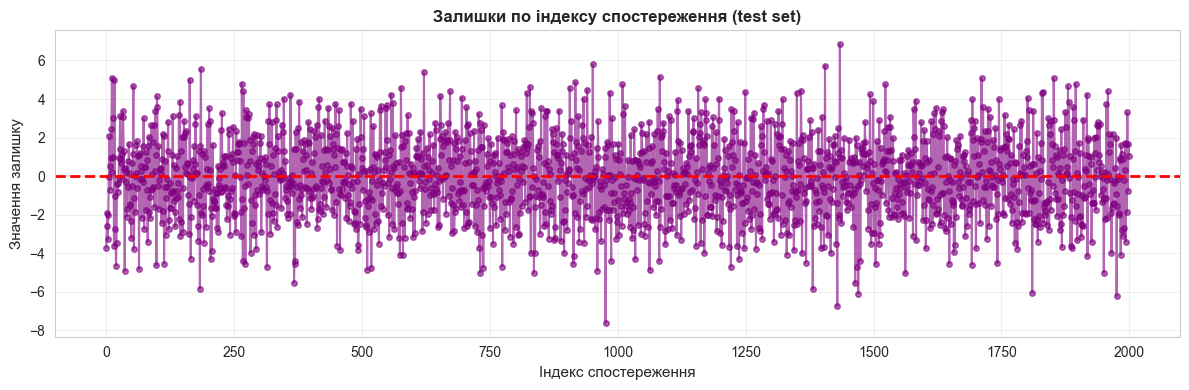

In [18]:
# Додатковий графік: залишки по порядку спостережень
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(test_residuals, marker='o', linestyle='-', alpha=0.6, color='purple', markersize=4)
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set_title("Залишки по індексу спостереження (test set)", fontsize=12, fontweight='bold')
ax.set_xlabel("Індекс спостереження", fontsize=11)
ax.set_ylabel("Значення залишку", fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# --- 10. Висновки (автоматичний короткий звіт) ---
print("\n" + "=" * 70)
print("ПІДСУМКОВИЙ ЗВІТ ПО МОДЕЛІ:")
print("=" * 70)
print(f"✓ Обрана цільова змінна: '{target_column}'")
print(f"✓ Кількість ознак після перетворень: {len(all_feature_names)}")
print(f"✓ Розмір тренувальної вибірки: {len(y_train)} спостережень")
print(f"✓ Розмір тестової вибірки: {len(y_test)} спостережень")
print()
print("ЯКІСТЬ МОДЕЛІ:")
print(f"  • Test MSE: {test_mse:.4f}")
print(f"  • Test R²: {test_r2:.4f} ({test_r2*100:.1f}% варіації пояснено)")
print(f"  • Baseline MSE: {baseline_mse:.4f}")
print()
print("ВИКОНАННЯ ПРИПУЩЕНЬ МНК (коротко):")
print(f"  1. Лінійність: перевірте графік 'Залишки vs Прогнози'")
print(f"  2. Мультиколінеарність: середній VIF = {vif_results['VIF'].mean():.2f}")
print(f"     → VIF < 5 - ОК, 5-10 - помірна, >10 - проблема")
print(f"  3. Нормальність залишків:")
print(f"     → Shapiro p = {shapiro_pvalue:.3f}, JB p = {jb_pvalue:.3f}")
print(f"     → p > 0.05 означає нормальність не відкидається")
print(f"  4. Гомоскедастичність: BP p-value = {bp_results[1]:.3f}")
print(f"     → p > 0.05 означає рівність дисперсій")
print(f"  5. Автокореляція: DW = {dw_statistic:.3f}")
print(f"     → Оптимально біля 2.0 (діапазон 1.5-2.5)")
print(f"  6. Впливові точки: {num_influential_obs} спостережень (>{cooks_threshold:.4f})")

print("\n" + "=" * 70)
print("РЕКОМЕНДАЦІЇ ДЛЯ ПОКРАЩЕННЯ МОДЕЛІ:")
print("=" * 70)
recommendations = []
if vif_results['VIF'].max() > 10:
    recommendations.append("⚠️  Високі VIF: розгляньте видалення корельованих ознак або застосуйте PCA")
if shapiro_pvalue < 0.05 or jb_pvalue < 0.05:
    recommendations.append("⚠️  Ненормальні залишки: спробуйте трансформації (log, sqrt) або робастні методи")
if bp_results[1] < 0.05:
    recommendations.append("⚠️  Гетероскедастичність: розгляньте зважену регресію або трансформацію")
if dw_statistic < 1.5 or dw_statistic > 2.5:
    recommendations.append("⚠️  Автокореляція: перевірте порядок даних або додайте лагові змінні")
if num_influential_obs > total_observations * 0.05:
    recommendations.append("⚠️  Багато впливових точок: перевірте на помилки у даних")
if test_r2 < 0.5:
    recommendations.append("⚠️  Низький R²: розгляньте додаткові ознаки або нелінійні моделі")

if recommendations:
    for rec in recommendations:
        print(f"  {rec}")
else:
    print("  ✓ Модель задовольняє всі основні припущення МНК!")
    print("  ✓ Результати можна вважати надійними.")

print("\n" + "=" * 70)
print("АНАЛІЗ ЗАВЕРШЕНО")
print("=" * 70)


ПІДСУМКОВИЙ ЗВІТ ПО МОДЕЛІ:
✓ Обрана цільова змінна: 'Performance Index'
✓ Кількість ознак після перетворень: 5
✓ Розмір тренувальної вибірки: 8000 спостережень
✓ Розмір тестової вибірки: 2000 спостережень

ЯКІСТЬ МОДЕЛІ:
  • Test MSE: 4.0826
  • Test R²: 0.9890 (98.9% варіації пояснено)
  • Baseline MSE: 370.7730

ВИКОНАННЯ ПРИПУЩЕНЬ МНК (коротко):
  1. Лінійність: перевірте графік 'Залишки vs Прогнози'
  2. Мультиколінеарність: середній VIF = 1.00
     → VIF < 5 - ОК, 5-10 - помірна, >10 - проблема
  3. Нормальність залишків:
     → Shapiro p = 0.975, JB p = 0.958
     → p > 0.05 означає нормальність не відкидається
  4. Гомоскедастичність: BP p-value = 0.240
     → p > 0.05 означає рівність дисперсій
  5. Автокореляція: DW = 2.047
     → Оптимально біля 2.0 (діапазон 1.5-2.5)
  6. Впливові точки: 493 спостережень (>0.0004)

РЕКОМЕНДАЦІЇ ДЛЯ ПОКРАЩЕННЯ МОДЕЛІ:
  ✓ Модель задовольняє всі основні припущення МНК!
  ✓ Результати можна вважати надійними.

АНАЛІЗ ЗАВЕРШЕНО
